In [1]:
import pandas as pd
import numpy as np
import joblib

In [2]:
model = joblib.load(
    "models/fraud_detection_model.pkl"
)

threshold = joblib.load(
    "models/fraud_threshold.pkl"
)

print("Modèle chargé avec succès ✅")
print("Seuil :", threshold)

Modèle chargé avec succès ✅
Seuil : 0.19999999999999996


In [3]:
def predict_fraud(model, threshold, data):
    """
    Prédit le risque de fraude pour un ou plusieurs dossiers.
    """

    probability = model.predict_proba(data)[:, 1]

    prediction = (
        probability >= threshold
    ).astype(int)

    result = pd.DataFrame({
        "fraud_probability": probability,
        "prediction": prediction
    })

    result["risk_level"] = result["fraud_probability"].apply(
        lambda x:
            "Faible" if x < 0.20
            else "Modéré" if x < 0.50
            else "Élevé"
    )

    result["decision"] = result["prediction"].map({
        0: "Non fraude",
        1: "Fraude"
    })

    return result

In [4]:
# =========================
# Préparation des données
# =========================

def prepare_input(df):
    df = df.copy()

    # Remplacer les valeurs "?" par NaN
    df = df.replace("?", np.nan)

    # Valeurs manquantes
    if "authorities_contacted" in df.columns:
        df["authorities_contacted"] = (
            df["authorities_contacted"].fillna("Unknown")
        )

    # Conversion des dates
    df["policy_bind_date"] = pd.to_datetime(
        df["policy_bind_date"]
    )

    df["incident_date"] = pd.to_datetime(
        df["incident_date"]
    )

    # Variables temporelles
    df["policy_bind_year"] = (
        df["policy_bind_date"].dt.year
    )

    df["policy_bind_month"] = (
        df["policy_bind_date"].dt.month
    )

    df["incident_year"] = (
        df["incident_date"].dt.year
    )

    df["incident_month"] = (
        df["incident_date"].dt.month
    )

    df["policy_duration_days"] = (
        df["incident_date"]
        - df["policy_bind_date"]
    ).dt.days

    # Âge du véhicule
    df["vehicle_age"] = (
        df["incident_date"].dt.year
        - df["auto_year"]
    )

    # Période de la journée
    def get_time_period(hour):
        if 6 <= hour < 12:
            return "Morning"
        elif 12 <= hour < 18:
            return "Afternoon"
        elif 18 <= hour < 24:
            return "Evening"
        else:
            return "Night"

    df["incident_period"] = (
        df["incident_hour_of_the_day"]
        .apply(get_time_period)
    )

    # Supprimer les variables inutiles
    columns_to_drop = [
        "policy_number",
        "incident_location",
        "insured_zip",
        "policy_bind_date",
        "incident_date",
        "_c39",
        "total_claim_amount",
        "injury_claim",
        "property_claim",
        "vehicle_claim",
        "fraud_reported"
    ]

    df = df.drop(
        columns=columns_to_drop,
        errors="ignore"
    )

    return df

In [5]:
insurance_claims = pd.read_csv(
    "insurance_claims.csv"
)

In [6]:
sample = insurance_claims.iloc[[0]].copy()

sample_prepared = prepare_input(sample)

print("Dimensions :", sample_prepared.shape)

sample_prepared.head()

Dimensions : (1, 36)


,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,auto_make,auto_model,auto_year,policy_bind_year,policy_bind_month,incident_year,incident_month,policy_duration_days,vehicle_age,incident_period
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,Saab,92x,2004,2014,10,2015,1,100,11,Night


In [7]:
result = predict_fraud(
    model,
    threshold,
    sample_prepared
)

result

,fraud_probability,prediction,risk_level,decision
0,0.7392,1,Élevé,Fraude


In [8]:
# =========================
# Test sur plusieurs dossiers
# =========================

samples = insurance_claims.iloc[:10].copy()

samples_prepared = prepare_input(samples)

results = predict_fraud(
    model,
    threshold,
    samples_prepared
)

results

,fraud_probability,prediction,risk_level,decision
0,0.739200,1,Élevé,Fraude
1,0.158509,0,Faible,Non fraude
2,0.116716,0,Faible,Non fraude
3,0.898010,1,Élevé,Fraude
4,0.093279,0,Faible,Non fraude
5,0.869292,1,Élevé,Fraude
6,0.088470,0,Faible,Non fraude
7,0.157082,0,Faible,Non fraude
8,0.068277,0,Faible,Non fraude
9,0.091459,0,Faible,Non fraude


In [9]:
# Ajouter l'identifiant du dossier
results_display = results.copy()

results_display.insert(
    0,
    "Dossier",
    range(1, len(results_display) + 1)
)

results_display

,Dossier,fraud_probability,prediction,risk_level,decision
0,1,0.739200,1,Élevé,Fraude
1,2,0.158509,0,Faible,Non fraude
2,3,0.116716,0,Faible,Non fraude
3,4,0.898010,1,Élevé,Fraude
4,5,0.093279,0,Faible,Non fraude
5,6,0.869292,1,Élevé,Fraude
6,7,0.088470,0,Faible,Non fraude
7,8,0.157082,0,Faible,Non fraude
8,9,0.068277,0,Faible,Non fraude
9,10,0.091459,0,Faible,Non fraude


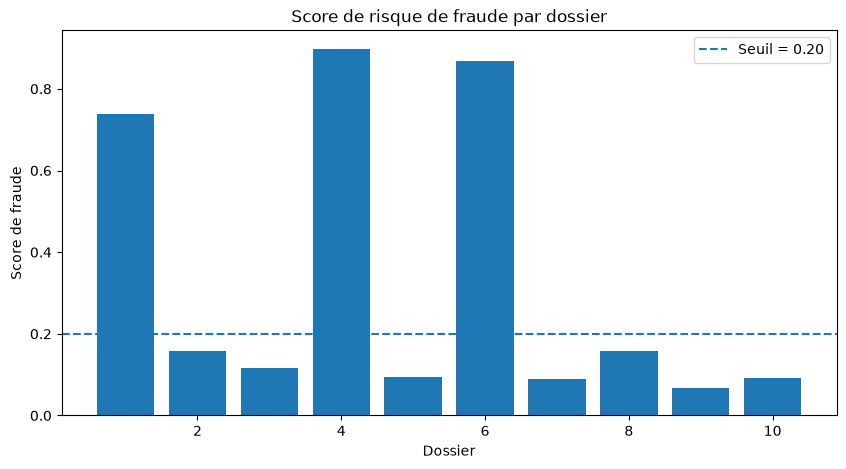

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_display["Dossier"],
    results_display["fraud_probability"]
)

plt.axhline(
    threshold,
    linestyle="--",
    label=f"Seuil = {threshold:.2f}"
)

plt.xlabel("Dossier")
plt.ylabel("Score de fraude")
plt.title("Score de risque de fraude par dossier")
plt.legend()

plt.show()